<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/02_RF_%EC%B5%9C%EC%A2%85%EA%B2%80%EC%A6%9D_%EC%8B%A0%EA%B7%9C%ED%99%98%EC%9E%90%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#02_RF_최종검증_신규환자예측.ipynb </br>
→ 저장 결과 불러오기</br>
→ 데이터 signature 재확인</br>
→ RF 확률 보정 비교</br>
→ 최종 파라미터·threshold 결정</br>
→ 최종 pipeline 학습·저장</br>
→ 신규 환자 입력</br>
→ 외부 데이터 검증</br>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import hashlib
import json
import joblib
import numpy as np
import pandas as pd
import sklearn

RF_RUN_DIR = Path(
    "/content/drive/MyDrive/"
    "clinical_rf_validation/"
    "rf_nested_20260828_030434"
)

required_files = [
    "rf_nested_result.joblib",
    "rf_pooled_metrics.json",
    "rf_selected_params.json",
    "rf_experiment_config.json",
    "rf_outer_splits.json",
    "environment.json",
    "signatures.json",
    "artifact_manifest.json"
]

missing_files = [
    filename
    for filename in required_files
    if not (
        RF_RUN_DIR / filename
    ).exists()
]

if missing_files:
    raise FileNotFoundError(
        f"누락된 저장 파일: {missing_files}"
    )

rf_nested = joblib.load(
    RF_RUN_DIR / "rf_nested_result.joblib"
)

with open(
    RF_RUN_DIR / "signatures.json",
    encoding="utf-8"
) as file:
    saved_signatures = json.load(file)

with open(
    RF_RUN_DIR / "rf_experiment_config.json",
    encoding="utf-8"
) as file:
    rf_experiment_config = json.load(file)

with open(
    RF_RUN_DIR / "environment.json",
    encoding="utf-8"
) as file:
    saved_environment = json.load(file)

print("✅ RF 저장 결과 불러오기 완료")
print("모델:", rf_nested["Model"])
print(
    "Outer fold 수:",
    len(rf_nested["FoldResults"])
)

display(
    pd.Series(
        rf_nested["PooledMetrics"]
    ).round(4)
)

print("\n저장된 실행 환경:")
display(
    pd.Series(saved_environment)
)

print("\n저장된 signature:")
display(
    pd.Series(saved_signatures)
)

✅ RF 저장 결과 불러오기 완료
모델: Random Forest
Outer fold 수: 10


,0
Threshold,NaN
Accuracy,0.8779
Precision,0.8841
Sensitivity,0.9537
Specificity,0.6897
F1,0.9176
PR_AUC,0.9709
ROC_AUC,0.9278
Brier,0.1233
ECE,0.1590



저장된 실행 환경:


,0
Python,3.13.15
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
NumPy,2.1.3
Pandas,2.2.3
ScikitLearn,1.6.1
Joblib,1.5.3



저장된 signature:


,0
DataSignature,95395cc5677ee93eb82410db7d0676ce21f8d8e4eba7cc...
CandidateSignature,4553f195fbdc720125e5eee368b01f2d6ced4d19df31e9...
OuterSplitSignature,844e7235551cfa636de535cfbd8c4328e7197171ff7408...
OOFProbabilitySignature,ed7631d027a07d9d576d5bd02ac533c712d3d16be89390...


In [3]:
#@title 데이터 입력 스키마 재현성 검사

from pathlib import Path
import hashlib
import pandas as pd

# 1. 원본 Excel 자동 검색
data_candidates = list(
    Path(
        "/content/drive/MyDrive"
    ).rglob(
        "extension of Z-Alizadeh sani dataset.xlsx"
    )
)

if len(data_candidates) != 1:
    raise RuntimeError(
        "원본 데이터 파일이 "
        f"{len(data_candidates)}개 검색됐습니다.\n"
        f"{data_candidates}"
    )

DATA_FILE = data_candidates[0]

print("원본 데이터:")
print(DATA_FILE)


# 2. 원본 데이터 다시 불러오기
df_raw = pd.read_excel(DATA_FILE)

assert df_raw.shape == (303, 59), (
    f"예상 shape (303, 59), "
    f"현재 shape {df_raw.shape}"
)


# 3. Target 생성
y_final = df_raw["Cath"].map({
    "Normal": 0,
    "CAD": 1
})

if y_final.isna().any():
    raise ValueError(
        "Cath에 정의되지 않은 값이 있습니다: "
        f"{df_raw.loc[y_final.isna(), 'Cath'].unique()}"
    )

y_final = y_final.astype(int)


# 4. 누수·상수 변수 제거
drop_cols_final = [
    "Cath",
    "LAD",
    "LCX",
    "RCA",
    "Exertional CP"
]

X_final = df_raw.drop(
    columns=drop_cols_final
).copy()


# 5. Y/N 이진 변수 변환
binary_cols_final = [
    "Obesity",
    "CRF",
    "CVA",
    "Airway disease",
    "Thyroid Disease",
    "CHF",
    "DLP",
    "Weak Peripheral Pulse",
    "Lung rales",
    "Systolic Murmur",
    "Diastolic Murmur",
    "Dyspnea",
    "Atypical",
    "Nonanginal",
    "LowTH Ang",
    "LVH",
    "Poor R Progression"
]

for column in binary_cols_final:
    mapped = X_final[column].map({
        "N": 0,
        "Y": 1
    })

    if mapped.isna().any():
        unknown_values = (
            X_final.loc[
                mapped.isna(),
                column
            ]
            .drop_duplicates()
            .tolist()
        )

        raise ValueError(
            f"{column}의 정의되지 않은 값: "
            f"{unknown_values}"
        )

    X_final[column] = mapped.astype(int)


# 6. 성별 변환
mapped_sex = X_final["Sex"].map({
    "Fmale": 0,
    "Male": 1
})

if mapped_sex.isna().any():
    raise ValueError(
        "Sex의 정의되지 않은 값: "
        f"{X_final.loc[mapped_sex.isna(), 'Sex'].unique()}"
    )

X_final["Sex"] = mapped_sex.astype(int)


# 7. 인덱스 통일
X_final = X_final.reset_index(drop=True)
y_final = y_final.reset_index(drop=True)


# 8. 기본 검증
assert X_final.shape == (303, 54)
assert y_final.value_counts().to_dict() == {
    1: 216,
    0: 87
}
assert X_final.isna().sum().sum() == 0

assert set(
    X_final["BBB"].unique()
).issubset({
    "N",
    "LBBB",
    "RBBB"
})

assert set(
    X_final["VHD"].unique()
).issubset({
    "N",
    "mild",
    "Moderate",
    "Severe"
})


# 9. 저장된 컬럼 순서와 비교
saved_columns = (
    rf_experiment_config["Columns"]
)

assert X_final.columns.tolist() == (
    saved_columns
), (
    "저장 당시와 현재의 컬럼 또는 "
    "컬럼 순서가 다릅니다."
)


# 10. Data signature 계산
signature_frame = pd.concat(
    [
        X_final.astype(str),
        y_final.rename(
            "__target__"
        ).astype(str)
    ],
    axis=1
)

current_data_signature = (
    hashlib.sha256(
        pd.util.hash_pandas_object(
            signature_frame,
            index=True
        ).values.tobytes()
    ).hexdigest()
)

saved_data_signature = (
    saved_signatures[
        "DataSignature"
    ]
)

print("\n저장 signature:")
print(saved_data_signature)

print("\n현재 signature:")
print(current_data_signature)

assert (
    current_data_signature
    == saved_data_signature
), (
    "❌ 저장 당시 데이터와 현재 데이터가 "
    "일치하지 않습니다."
)


print("\n✅ 원본 데이터 shape 확인")
print("✅ Target 분포 확인")
print("✅ 누수·상수 변수 제거 확인")
print("✅ 결측값 없음 확인")
print("✅ 범주값 확인")
print("✅ 54개 입력 컬럼 및 순서 확인")
print("✅ Data signature 완전 일치")
print("\nRF 최종 검증용 데이터 준비 완료")

원본 데이터:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/Z-Alizadeh/extension of Z-Alizadeh sani dataset.xlsx

저장 signature:
95395cc5677ee93eb82410db7d0676ce21f8d8e4eba7cc84ebd55d221db1c8ff

현재 signature:
95395cc5677ee93eb82410db7d0676ce21f8d8e4eba7cc84ebd55d221db1c8ff

✅ 원본 데이터 shape 확인
✅ Target 분포 확인
✅ 누수·상수 변수 제거 확인
✅ 결측값 없음 확인
✅ 범주값 확인
✅ 54개 입력 컬럼 및 순서 확인
✅ Data signature 완전 일치

RF 최종 검증용 데이터 준비 완료


In [5]:
#@title RF 최종 모델용 공통 전처리•평가 함수

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = int(
    rf_experiment_config["Seed"]
)

MIN_SENSITIVITY = float(
    rf_experiment_config[
        "MinimumSensitivity"
    ]
)

N_ECE_BINS = int(
    rf_experiment_config["ECEBins"]
)

# 1. 입력 변수 그룹
categorical_bbb = ["BBB"]
ordinal_vhd = ["VHD"]

numeric_cols_final = [
    column
    for column in X_final.columns
    if column not in (
        categorical_bbb
        + ordinal_vhd
    )
]

assert len(numeric_cols_final) == 52


# 2. 저장 당시와 동일한 전처리기
def make_final_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                "passthrough",
                numeric_cols_final
            ),
            (
                "bbb",
                OneHotEncoder(
                    categories=[[
                        "N",
                        "LBBB",
                        "RBBB"
                    ]],
                    drop=["N"],
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_bbb
            ),
            (
                "vhd",
                OrdinalEncoder(
                    categories=[[
                        "N",
                        "mild",
                        "Moderate",
                        "Severe"
                    ]],
                    handle_unknown=(
                        "use_encoded_value"
                    ),
                    unknown_value=-1
                ),
                ordinal_vhd
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )


# 3. 안전한 나눗셈
def safe_divide(
    numerator,
    denominator
):
    if denominator == 0:
        return 0.0

    return numerator / denominator


# 4. Expected Calibration Error
def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=N_ECE_BINS
):
    y_true = np.asarray(
        y_true
    ).astype(int)

    y_prob = np.asarray(
        y_prob
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    bin_ids = np.digitize(
        y_prob,
        bin_edges[1:-1],
        right=True
    )

    ece = 0.0
    sample_count = len(y_true)

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if not np.any(mask):
            continue

        observed_rate = (
            y_true[mask].mean()
        )

        predicted_rate = (
            y_prob[mask].mean()
        )

        bin_weight = (
            mask.sum() / sample_count
        )

        ece += (
            bin_weight
            * abs(
                observed_rate
                - predicted_rate
            )
        )

    return float(ece)


# 5. 이진분류 평가 함수
def calculate_binary_metrics(
    y_true,
    y_prob,
    threshold=None,
    y_pred=None
):
    y_true = np.asarray(
        y_true
    ).astype(int)

    y_prob = np.asarray(
        y_prob
    ).astype(float)

    if y_pred is None:
        if threshold is None:
            raise ValueError(
                "threshold 또는 "
                "y_pred가 필요합니다."
            )

        y_pred = (
            y_prob >= threshold
        ).astype(int)

    y_pred = np.asarray(
        y_pred
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()
    )

    return {
        "Threshold": (
            float(threshold)
            if threshold is not None
            else np.nan
        ),
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Sensitivity": safe_divide(
            tp,
            tp + fn
        ),
        "Specificity": safe_divide(
            tn,
            tn + fp
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "PR_AUC": (
            average_precision_score(
                y_true,
                y_prob
            )
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "Brier": float(
            np.mean(
                (y_true - y_prob) ** 2
            )
        ),
        "ECE": (
            expected_calibration_error(
                y_true,
                y_prob
            )
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


# 6. Sensitivity 95% 우선 threshold
def select_clinical_threshold(
    y_true,
    y_prob,
    min_sensitivity=MIN_SENSITIVITY
):
    y_true = np.asarray(
        y_true
    ).astype(int)

    y_prob = np.asarray(
        y_prob
    ).astype(float)

    candidate_thresholds = np.unique(
        np.concatenate([
            np.array([0.0]),
            y_prob,
            np.array([1.0])
        ])
    )

    valid_candidates = []

    for threshold in candidate_thresholds:
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        tn, fp, fn, tp = (
            confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()
        )

        sensitivity = safe_divide(
            tp,
            tp + fn
        )

        specificity = safe_divide(
            tn,
            tn + fp
        )

        if (
            sensitivity
            >= min_sensitivity
        ):
            valid_candidates.append({
                "Threshold": float(
                    threshold
                ),
                "Sensitivity": sensitivity,
                "Specificity": specificity
            })

    if not valid_candidates:
        raise RuntimeError(
            "Sensitivity 조건을 만족하는 "
            "threshold가 없습니다."
        )

    best_candidate = max(
        valid_candidates,
        key=lambda row: (
            row["Specificity"],
            row["Sensitivity"],
            row["Threshold"]
        )
    )

    return best_candidate[
        "Threshold"
    ]


# 7. 전처리 출력 구조 검사
preprocessor_check = (
    make_final_preprocessor()
)

X_transformed_check = (
    preprocessor_check.fit_transform(
        X_final
    )
)

feature_names_check = (
    preprocessor_check
    .get_feature_names_out()
    .tolist()
)

assert X_transformed_check.shape == (
    303,
    55
)

assert len(feature_names_check) == 55

assert feature_names_check[-3:] == [
    "BBB_LBBB",
    "BBB_RBBB",
    "VHD"
]

print("✅ 공통 전처리·평가 함수 준비 완료")
print("원본 입력:", X_final.shape)
print(
    "전처리 후 입력:",
    X_transformed_check.shape
)
print(
    "수치·이진 변수:",
    len(numeric_cols_final)
)
print(
    "마지막 변환 변수:",
    feature_names_check[-3:]
)
print(
    "Sensitivity 최소 기준:",
    MIN_SENSITIVITY
)

# 구조 확인용 데이터는 실제 모델에 사용하지 않음
del preprocessor_check
del X_transformed_check

✅ 공통 전처리·평가 함수 준비 완료
원본 입력: (303, 54)
전처리 후 입력: (303, 55)
수치·이진 변수: 52
마지막 변환 변수: ['BBB_LBBB', 'BBB_RBBB', 'VHD']
Sensitivity 최소 기준: 0.95


In [6]:
#@title 전체 개발 데이터의 5-Fold OOF로 최종 RF 파라미터 하나 선정

# 전체 개발 데이터에서 최종 RF 파라미터 선택
# 24 candidates x 5 folds = 120회 학습

import hashlib
import json

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold
)
from sklearn.ensemble import (
    RandomForestClassifier
)


# 1. 저장된 후보를 그대로 불러오기
final_rf_candidates = (
    rf_experiment_config[
        "SampledParameters"
    ]
)

assert len(final_rf_candidates) == 24


# 2. 후보 signature 재검증
current_candidate_signature = (
    hashlib.sha256(
        json.dumps(
            final_rf_candidates,
            sort_keys=True,
            default=str
        ).encode("utf-8")
    ).hexdigest()
)

saved_candidate_signature = (
    saved_signatures[
        "CandidateSignature"
    ]
)

print("저장 Candidate signature:")
print(saved_candidate_signature)

print("\n현재 Candidate signature:")
print(current_candidate_signature)

assert (
    current_candidate_signature
    == saved_candidate_signature
), (
    "저장 당시와 현재의 RF 후보가 "
    "일치하지 않습니다."
)

print("\n✅ RF 후보 24개 완전 일치")

# 3. 최종 모델 구성용 5-Fold
final_rf_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# 4. 후보별 OOF 평가
final_rf_selection_results =[]
best_final_rf = None

for candidate_index, params in enumerate(
    final_rf_candidates,
    start =1
):
    print(
        f"RF candidate"
        f"{candidate_index:02d}/"
        f"{len(final_rf_candidates)}",
        flush=True
    )

    candidate_oof_probability = (
        np.zeros(
            len(y_final),
            dtype=float
        )
    )

    for train_idx, val_idx in (
        final_rf_cv.split(
            X_final,
            y_final
        )
    ):
        X_train_fold = X_final.iloc[
            train_idx
        ]

        y_train_fold = y_final.iloc[
            train_idx
        ]

        X_val_fold = X_final.iloc[
            val_idx
        ]

        fold_rf = (
            RandomForestClassifier(
                random_state = SEED,
                n_jobs = -1
            )
            .set_params(**params)
        )

        fold_pipeline = Pipeline([
            (
                "preprocessor",
                make_final_preprocessor()
            ),
            (
                "model",
                fold_rf
            )
        ])

        fold_pipeline.fit(
            X_train_fold,
            y_train_fold
        )

        candidate_oof_probability[
            val_idx
        ] =(
            fold_pipeline
            .predict_proba(
                X_val_fold
            )[:,1]
        )

    candidate_threshold = (
        select_clinical_threshold(
            y_final,
            candidate_oof_probability
        )
    )

    candidate_metrics = (
        calculate_binary_metrics(
            y_final,
            candidate_oof_probability,
            threshold=(
                candidate_threshold
            )
        )
    )

    # Sensitivity 95% 조건은 threshold
    # 선택 과정에서 이미 적용됨
    candidate_rank = (
        candidate_metrics[
            "Specificity"
        ],
        candidate_metrics[
            "PR_AUC"
        ],
        candidate_metrics[
            "ROC_AUC"
        ],
        -candidate_metrics[
            "Brier"
        ],
        -candidate_metrics[
            "ECE"
        ]
    )

    final_rf_selection_results.append({
        "Candidate": candidate_index,
        "Params": params.copy(),
        **candidate_metrics,
        "Rank": candidate_rank
    })

    if (
        best_final_rf is None
        or candidate_rank
        > best_final_rf["Rank"]
    ):
        best_final_rf = {
            "Candidate": candidate_index,
            "Params": params.copy(),
            "Threshold": (
                candidate_threshold
            ),
            "Metrics": (
                candidate_metrics.copy()
            ),
            "OOFProbability": (
                candidate_oof_probability
                .copy()
            ),
            "Rank": candidate_rank
        }


# 5. 결과표 생성
final_rf_selection_df = (
    pd.DataFrame(
        final_rf_selection_results
    )
    .sort_values(
        by=[
            "Specificity",
            "PR_AUC",
            "ROC_AUC",
            "Brier",
            "ECE"
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


# 6. 다음 단계에서 사용할 변수
best_rf_candidate = (
    best_final_rf["Candidate"]
)

best_rf_params = (
    best_final_rf["Params"]
)

raw_rf_threshold = (
    best_final_rf["Threshold"]
)

raw_rf_oof_probability = (
    best_final_rf[
        "OOFProbability"
    ]
)

raw_rf_oof_prediction = (
    raw_rf_oof_probability
    >= raw_rf_threshold
).astype(int)


# 7. 최종 출력
print(
    "\n=== 최종 RF 구성용 "
    "파라미터 선택 결과 ==="
)

print(
    "선택 Candidate:",
    best_rf_candidate
)

print("\n최종 파라미터:")
print(best_rf_params)

print(
    "\nRaw RF OOF threshold:",
    round(
        raw_rf_threshold,
        6
    )
)

print("\nRaw RF OOF 지표:")
display(
    pd.Series(
        best_final_rf["Metrics"]
    ).round(4)
)

print("\n상위 5개 후보:")
display(
    final_rf_selection_df[
        [
            "Candidate",
            "Threshold",
            "Sensitivity",
            "Specificity",
            "PR_AUC",
            "ROC_AUC",
            "Brier",
            "ECE",
            "Params"
        ]
    ].head(5)
)

저장 Candidate signature:
4553f195fbdc720125e5eee368b01f2d6ced4d19df31e95008b50bcebc7868ca

현재 Candidate signature:
4553f195fbdc720125e5eee368b01f2d6ced4d19df31e95008b50bcebc7868ca

✅ RF 후보 24개 완전 일치
RF candidate01/24
RF candidate02/24
RF candidate03/24
RF candidate04/24
RF candidate05/24
RF candidate06/24
RF candidate07/24
RF candidate08/24
RF candidate09/24
RF candidate10/24
RF candidate11/24
RF candidate12/24
RF candidate13/24
RF candidate14/24
RF candidate15/24
RF candidate16/24
RF candidate17/24
RF candidate18/24
RF candidate19/24
RF candidate20/24
RF candidate21/24
RF candidate22/24
RF candidate23/24
RF candidate24/24

=== 최종 RF 구성용 파라미터 선택 결과 ===
선택 Candidate: 19

최종 파라미터:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 12, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}

Raw RF OOF threshold: 0.419485

Raw RF OOF 지표:


,0
Threshold,0.4195
Accuracy,0.8746
Precision,0.8803
Sensitivity,0.9537
Specificity,0.6782
F1,0.9156
PR_AUC,0.9649
ROC_AUC,0.9177
Brier,0.1245
ECE,0.1567



상위 5개 후보:


,Candidate,Threshold,Sensitivity,Specificity,PR_AUC,ROC_AUC,Brier,ECE,Params
0,19,0.419485,0.953704,0.678161,0.964928,0.917731,0.124526,0.156706,"{'n_estimators': 400, 'min_samples_split': 10,..."
1,14,0.396442,0.958333,0.655172,0.965371,0.916720,0.123644,0.149971,"{'n_estimators': 200, 'min_samples_split': 5, ..."
2,3,0.401345,0.953704,0.655172,0.963756,0.914857,0.126189,0.160388,"{'n_estimators': 200, 'min_samples_split': 10,..."
3,17,0.492500,0.953704,0.632184,0.966317,0.921243,0.112994,0.110371,"{'n_estimators': 400, 'min_samples_split': 2, ..."
4,18,0.418849,0.953704,0.620690,0.969710,0.925819,0.135009,0.192458,"{'n_estimators': 200, 'min_samples_split': 5, ..."


In [8]:
#@title Raw / Sigmoid / Isotonic OOF 비교

# Raw RF / Sigmoid / Isotonic calibration 비교
# 최종 모델 구성용 OOF 평가이며 외부 검증 결과가 아님

# Calibration도 누수되지 않도록 각 outer training fold 내부에서만 학습하고,
# 해당 outer validation fold에 예측

# Raw RF / Sigmoid / Isotonic calibration 비교
# 최종 모델 구성용 OOF 평가이며 외부 검증 결과가 아님

from sklearn.calibration import (
    CalibratedClassifierCV
)


calibration_methods = [
    "sigmoid",
    "isotonic"
]

calibration_oof_probabilities = {
    "Raw RF": (
        raw_rf_oof_probability.copy()
    )
}

calibration_thresholds = {}
calibration_metrics = {}


# 1. 보정 모델별 OOF 확률 생성
for method in calibration_methods:
    print(
        f"\n[{method}] calibration 시작",
        flush=True
    )

    method_oof_probability = np.full(
        len(y_final),
        np.nan,
        dtype=float
    )

    for outer_fold, (
        train_idx,
        val_idx
    ) in enumerate(
        final_rf_cv.split(
            X_final,
            y_final
        ),
        start=1
    ):
        print(
            f"  Fold {outer_fold}/5",
            flush=True
        )

        X_train_fold = X_final.iloc[
            train_idx
        ]

        y_train_fold = y_final.iloc[
            train_idx
        ]

        X_val_fold = X_final.iloc[
            val_idx
        ]

        fold_rf = (
            RandomForestClassifier(
                random_state=SEED,
                n_jobs=-1
            )
            .set_params(
                **best_rf_params
            )
        )

        fold_pipeline = Pipeline([
            (
                "preprocessor",
                make_final_preprocessor()
            ),
            (
                "model",
                fold_rf
            )
        ])

        # Calibration도 outer train 내부에서만 수행
        inner_calibration_cv = (
            StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=(
                    SEED
                    + outer_fold
                )
            )
        )

        calibrated_model = (
            CalibratedClassifierCV(
                estimator=fold_pipeline,
                method=method,
                cv=inner_calibration_cv,
                ensemble=False,
                n_jobs=1
            )
        )

        calibrated_model.fit(
            X_train_fold,
            y_train_fold
        )

        method_oof_probability[
            val_idx
        ] = (
            calibrated_model
            .predict_proba(
                X_val_fold
            )[:, 1]
        )

        del calibrated_model
        del fold_pipeline
        del fold_rf

    assert not np.isnan(
        method_oof_probability
    ).any(), (
        f"{method} OOF 확률에 "
        "누락값이 있습니다."
    )

    calibration_oof_probabilities[
        method.capitalize()
    ] = method_oof_probability


# 2. 각 방법의 threshold와 성능 계산
for method_name, oof_probability in (
    calibration_oof_probabilities.items()
):
    method_threshold = (
        select_clinical_threshold(
            y_final,
            oof_probability
        )
    )

    method_metrics = (
        calculate_binary_metrics(
            y_final,
            oof_probability,
            threshold=method_threshold
        )
    )

    calibration_thresholds[
        method_name
    ] = method_threshold

    calibration_metrics[
        method_name
    ] = method_metrics


# 3. 비교표
calibration_comparison_df = (
    pd.DataFrame(
        calibration_metrics
    )
    .T[
        [
            "Threshold",
            "Accuracy",
            "Precision",
            "Sensitivity",
            "Specificity",
            "F1",
            "PR_AUC",
            "ROC_AUC",
            "Brier",
            "ECE",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

display(
    calibration_comparison_df.round(4)
)


# 4. Raw RF 값이 이전 결과와 같은지 검증
assert np.isclose(
    calibration_comparison_df.loc[
        "Raw RF",
        "Sensitivity"
    ],
    0.9537037037
)

assert np.isclose(
    calibration_comparison_df.loc[
        "Raw RF",
        "Specificity"
    ],
    0.6781609195
)

print(
    "\n✅ Raw RF 결과 재확인 완료"
)

print(
    "✅ Sigmoid·Isotonic calibration "
    "OOF 비교 완료"
)


[sigmoid] calibration 시작
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[isotonic] calibration 시작
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5


,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,PR_AUC,ROC_AUC,Brier,ECE,TN,FP,FN,TP
Raw RF,0.4195,0.8746,0.8803,0.9537,0.6782,0.9156,0.9649,0.9177,0.1245,0.1567,59.0,28.0,10.0,206.0
Sigmoid,0.3558,0.8779,0.8809,0.9583,0.6782,0.9180,0.9620,0.9127,0.1015,0.0501,59.0,28.0,9.0,207.0
Isotonic,0.3333,0.8713,0.8766,0.9537,0.6667,0.9135,0.9604,0.9170,0.1033,0.0426,58.0,29.0,10.0,206.0



✅ Raw RF 결과 재확인 완료
✅ Sigmoid·Isotonic calibration OOF 비교 완료


최종 RF 파라미터:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 12, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}

최종 calibration: sigmoid
최종 OOF threshold: 0.3558017639

최종 모델 학습 시작
✅ 전체 303명 최종 모델 학습 완료

최종 모델 저장 위치:
/content/drive/MyDrive/clinical_rf_validation/rf_nested_20260828_030434/final_rf_sigmoid_20260828_072752


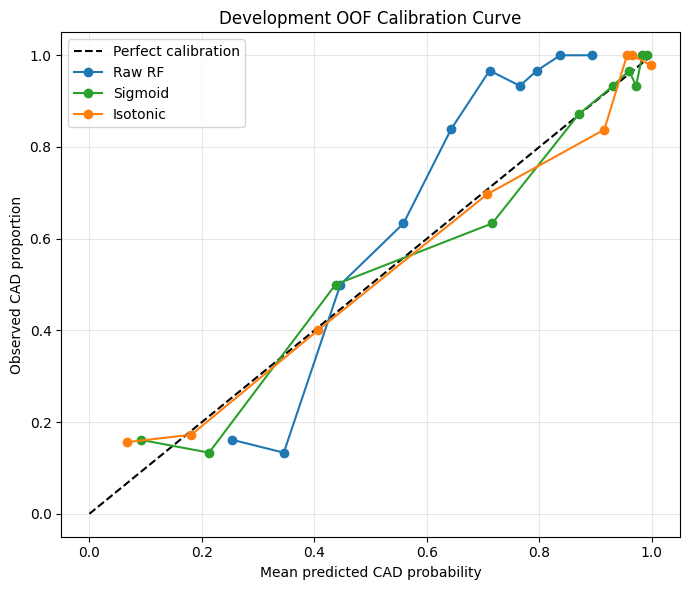

✅ 저장 모델 재로딩 검증 통과
✅ 허용오차 내 예측 확률 일치
✅ threshold 판정 완전 일치

✅ RF + Sigmoid 최종 모델 저장 완료
✅ 저장 모델 재로딩 완료
✅ 재로딩 전후 예측 확률 완전 일치
✅ threshold·입력 스키마 일치

최종 저장 폴더:
/content/drive/MyDrive/clinical_rf_validation/rf_nested_20260828_030434/final_rf_sigmoid_20260828_072752

최종 운영 threshold: 0.3558017639

모델 파일 SHA-256:
43fdf7f22dd7aed1d9d2338325b67018b9394d9a756ca75e88f141a595d451ac


In [11]:
#@title 최종 RF + Sigmoid 모델 학습 및 전체 산출물 저장

from pathlib import Path
from datetime import datetime

import hashlib
import json
import joblib
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)
from sklearn.ensemble import (
    RandomForestClassifier
)
from sklearn.model_selection import (
    StratifiedKFold
)
from sklearn.pipeline import Pipeline

# --------------------------------------------------
# 1. 최종 설정 고정
# --------------------------------------------------

FINAL_CALIBRATION_METHOD = "sigmoid"

final_threshold = float(
    calibration_thresholds[
        "Sigmoid"
    ]
)

final_rf_params = (
    best_rf_params.copy()
)

print("최종 RF 파라미터:")
print(final_rf_params)

print(
    "\n최종 calibration:",
    FINAL_CALIBRATION_METHOD
)

print(
    "최종 OOF threshold:",
    f"{final_threshold:.10f}"
)


# --------------------------------------------------
# 2. 전체 데이터로 최종 모델 학습
# --------------------------------------------------

final_rf_estimator = (
    RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    )
    .set_params(
        **final_rf_params
    )
)

final_base_pipeline = Pipeline([
    (
        "preprocessor",
        make_final_preprocessor()
    ),
    (
        "model",
        final_rf_estimator
    )
])

final_calibration_cv = (
    StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )
)

final_rf_sigmoid_model = (
    CalibratedClassifierCV(
        estimator=final_base_pipeline,
        method="sigmoid",
        cv=final_calibration_cv,
        ensemble=False,
        n_jobs=1
    )
)

print("\n최종 모델 학습 시작")

final_rf_sigmoid_model.fit(
    X_final,
    y_final
)

print("✅ 전체 303명 최종 모델 학습 완료")


# --------------------------------------------------
# 3. 저장 폴더 생성
# --------------------------------------------------

final_run_id = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

RF_FINAL_DIR = (
    RF_RUN_DIR
    / f"final_rf_sigmoid_{final_run_id}"
)

RF_FINAL_DIR.mkdir(
    parents=True,
    exist_ok=False
)

print("\n최종 모델 저장 위치:")
print(RF_FINAL_DIR)


# --------------------------------------------------
# 4. JSON 변환 함수
# --------------------------------------------------

def final_json_default(value):
    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    return str(value)


# --------------------------------------------------
# 5. Calibration 비교표 저장
# --------------------------------------------------

calibration_comparison_df.to_csv(
    RF_FINAL_DIR
    / "calibration_comparison.csv",
    encoding="utf-8-sig"
)

with open(
    RF_FINAL_DIR
    / "calibration_metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        calibration_metrics,
        file,
        ensure_ascii=False,
        indent=2,
        default=final_json_default
    )

with open(
    RF_FINAL_DIR
    / "calibration_thresholds.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        calibration_thresholds,
        file,
        ensure_ascii=False,
        indent=2,
        default=final_json_default
    )


# --------------------------------------------------
# 6. Calibration OOF 확률 저장
# --------------------------------------------------

calibration_oof_df = pd.DataFrame({
    "RowIndex": np.arange(
        len(y_final)
    ),
    "TrueLabel": np.asarray(
        y_final
    ),
    "RawRFProbability": (
        calibration_oof_probabilities[
            "Raw RF"
        ]
    ),
    "SigmoidProbability": (
        calibration_oof_probabilities[
            "Sigmoid"
        ]
    ),
    "IsotonicProbability": (
        calibration_oof_probabilities[
            "Isotonic"
        ]
    )
})

for method_name in [
    "Raw RF",
    "Sigmoid",
    "Isotonic"
]:
    probability_column = {
        "Raw RF": "RawRFProbability",
        "Sigmoid": "SigmoidProbability",
        "Isotonic": "IsotonicProbability"
    }[method_name]

    prediction_column = (
        method_name
        .replace(" ", "")
        + "Prediction"
    )

    calibration_oof_df[
        prediction_column
    ] = (
        calibration_oof_df[
            probability_column
        ]
        >= calibration_thresholds[
            method_name
        ]
    ).astype(int)

calibration_oof_df.to_csv(
    RF_FINAL_DIR
    / "calibration_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

np.savez_compressed(
    RF_FINAL_DIR
    / "calibration_oof_predictions.npz",
    row_index=np.arange(
        len(y_final)
    ),
    y_true=np.asarray(y_final),
    raw_probability=(
        calibration_oof_probabilities[
            "Raw RF"
        ]
    ),
    sigmoid_probability=(
        calibration_oof_probabilities[
            "Sigmoid"
        ]
    ),
    isotonic_probability=(
        calibration_oof_probabilities[
            "Isotonic"
        ]
    )
)


# --------------------------------------------------
# 7. 최종 후보 선택 결과 저장
# --------------------------------------------------

final_rf_selection_df.to_csv(
    RF_FINAL_DIR
    / "final_rf_candidate_selection.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    RF_FINAL_DIR
    / "final_rf_params.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_rf_params,
        file,
        ensure_ascii=False,
        indent=2,
        default=final_json_default
    )


# --------------------------------------------------
# 8. 입력 스키마와 신규 환자 양식 저장
# --------------------------------------------------

schema_records = []

for position, column in enumerate(
    X_final.columns
):
    unique_values = (
        X_final[column]
        .dropna()
        .unique()
        .tolist()
    )

    if column == "BBB":
        variable_type = "categorical"
        allowed_values = (
            "N|LBBB|RBBB"
        )
        observed_min = None
        observed_max = None

    elif column == "VHD":
        variable_type = "ordinal"
        allowed_values = (
            "N|mild|Moderate|Severe"
        )
        observed_min = None
        observed_max = None

    elif set(unique_values).issubset(
        {0, 1}
    ):
        variable_type = "binary"
        allowed_values = "0|1"
        observed_min = 0
        observed_max = 1

    else:
        variable_type = "numeric"
        allowed_values = None
        observed_min = float(
            X_final[column].min()
        )
        observed_max = float(
            X_final[column].max()
        )

    schema_records.append({
        "Position": position,
        "Column": column,
        "VariableType": variable_type,
        "PandasDtype": str(
            X_final[column].dtype
        ),
        "AllowedValues": allowed_values,
        "ObservedMin": observed_min,
        "ObservedMax": observed_max
    })

input_schema_df = pd.DataFrame(
    schema_records
)

input_schema_df.to_csv(
    RF_FINAL_DIR
    / "input_schema.csv",
    index=False,
    encoding="utf-8-sig"
)

new_patient_template = pd.DataFrame(
    [
        {
            column: np.nan
            for column
            in X_final.columns
        }
    ]
)

new_patient_template.to_csv(
    RF_FINAL_DIR
    / "new_patient_template.csv",
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------------
# 9. 최종 모델 저장
# --------------------------------------------------

FINAL_MODEL_FILE = (
    RF_FINAL_DIR
    / "final_rf_sigmoid_model.joblib"
)

joblib.dump(
    final_rf_sigmoid_model,
    FINAL_MODEL_FILE,
    compress=3
)


# --------------------------------------------------
# 10. 저장 무결성 검사용 기준 예측
# --------------------------------------------------
# 아래 값은 학습 데이터 성능 평가에 사용하지 않음

reference_probability = (
    final_rf_sigmoid_model
    .predict_proba(
        X_final
    )[:, 1]
)

reference_prediction = (
    reference_probability
    >= final_threshold
).astype(int)

np.savez_compressed(
    RF_FINAL_DIR
    / "artifact_reference_predictions.npz",
    probability=reference_probability,
    prediction=reference_prediction
)

reference_probability_hash = (
    hashlib.sha256(
        np.asarray(
            reference_probability,
            dtype=np.float64
        ).tobytes()
    ).hexdigest()
)


# --------------------------------------------------
# 11. Calibration curve 저장
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Perfect calibration"
)

colors = {
    "Raw RF": "tab:blue",
    "Sigmoid": "tab:green",
    "Isotonic": "tab:orange"
}

for method_name, probability in (
    calibration_oof_probabilities.items()
):
    observed_probability, (
        predicted_probability
    ) = calibration_curve(
        y_final,
        probability,
        n_bins=10,
        strategy="quantile"
    )

    ax.plot(
        predicted_probability,
        observed_probability,
        marker="o",
        label=method_name,
        color=colors[method_name]
    )

ax.set_xlabel(
    "Mean predicted CAD probability"
)

ax.set_ylabel(
    "Observed CAD proportion"
)

ax.set_title(
    "Development OOF Calibration Curve"
)

ax.legend()
ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RF_FINAL_DIR
    / "development_oof_calibration_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 12. 최종 메타데이터 저장
# --------------------------------------------------

sigmoid_oof_metrics = {
    key: final_json_default(value)
    for key, value
    in calibration_metrics[
        "Sigmoid"
    ].items()
}

final_metadata = {
    "ArtifactType": (
        "Final development model"
    ),
    "Model": (
        "RandomForestClassifier"
    ),
    "Calibration": "sigmoid",
    "CalibrationCV": {
        "Type": "StratifiedKFold",
        "Folds": 5,
        "Shuffle": True,
        "RandomState": SEED,
        "Ensemble": False
    },
    "FinalRFParams": final_rf_params,
    "OperatingThreshold": (
        final_threshold
    ),
    "ThresholdPolicy": (
        "Development OOF: "
        "Sensitivity >= 0.95, "
        "then maximize Specificity"
    ),
    "SigmoidDevelopmentOOFMetrics": (
        sigmoid_oof_metrics
    ),
    "DevelopmentSampleCount": (
        len(y_final)
    ),
    "TargetDistribution": {
        str(key): int(value)
        for key, value
        in y_final.value_counts()
        .sort_index()
        .items()
    },
    "RawInputCount": (
        X_final.shape[1]
    ),
    "TransformedInputCount": 55,
    "InputColumns": (
        X_final.columns.tolist()
    ),
    "ExcludedColumns": [
        "Cath",
        "LAD",
        "LCX",
        "RCA",
        "Exertional CP"
    ],
    "DataSignature": (
        current_data_signature
    ),
    "NestedCVRunDirectory": (
        str(RF_RUN_DIR)
    ),
    "ReferenceProbabilitySHA256": (
        reference_probability_hash
    ),
    "ImportantWarning": (
        "Development OOF results are not "
        "external validation performance."
    ),
    "Environment": {
        "Python": (
            platform.python_version()
        ),
        "NumPy": np.__version__,
        "Pandas": pd.__version__,
        "ScikitLearn": (
            sklearn.__version__
        ),
        "Joblib": joblib.__version__
    }
}

with open(
    RF_FINAL_DIR
    / "final_model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_metadata,
        file,
        ensure_ascii=False,
        indent=2,
        default=final_json_default
    )


# --------------------------------------------------
# 13. 모델 파일 SHA-256
# --------------------------------------------------

with open(
    FINAL_MODEL_FILE,
    "rb"
) as file:
    final_model_file_hash = (
        hashlib.sha256(
            file.read()
        ).hexdigest()
    )

artifact_manifest = {
    "ModelFile": (
        FINAL_MODEL_FILE.name
    ),
    "ModelFileSHA256": (
        final_model_file_hash
    ),
    "ReferenceProbabilitySHA256": (
        reference_probability_hash
    ),
    "MetadataFile": (
        "final_model_metadata.json"
    ),
    "InputSchemaFile": (
        "input_schema.csv"
    ),
    "PatientTemplateFile": (
        "new_patient_template.csv"
    )
}

with open(
    RF_FINAL_DIR
    / "artifact_manifest.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        artifact_manifest,
        file,
        ensure_ascii=False,
        indent=2
    )


# --------------------------------------------------
# 14. 재로딩 검증
# --------------------------------------------------

loaded_final_model = joblib.load(
    FINAL_MODEL_FILE
)

loaded_probability = (
    loaded_final_model
    .predict_proba(
        X_final
    )[:, 1]
)

assert np.allclose(
    loaded_probability,
    reference_probability,
    rtol=1e-10,
    atol=1e-12
)

assert np.array_equal(
    loaded_class,
    reference_class
)

print("✅ 저장 모델 재로딩 검증 통과")
print("✅ 허용오차 내 예측 확률 일치")
print("✅ threshold 판정 완전 일치")

assert np.all(
    (loaded_probability >= 0)
    & (loaded_probability <= 1)
)

with open(
    RF_FINAL_DIR
    / "final_model_metadata.json",
    encoding="utf-8"
) as file:
    loaded_metadata = json.load(file)

assert loaded_metadata[
    "InputColumns"
] == X_final.columns.tolist()

assert np.isclose(
    loaded_metadata[
        "OperatingThreshold"
    ],
    final_threshold
)


print(
    "\n✅ RF + Sigmoid 최종 모델 저장 완료"
)

print(
    "✅ 저장 모델 재로딩 완료"
)

print(
    "✅ 재로딩 전후 예측 확률 완전 일치"
)

print(
    "✅ threshold·입력 스키마 일치"
)

print("\n최종 저장 폴더:")
print(RF_FINAL_DIR)

print(
    "\n최종 운영 threshold:",
    f"{final_threshold:.10f}"
)

print(
    "\n모델 파일 SHA-256:"
)
print(final_model_file_hash)

In [10]:
# 저장 전후 예측 확률 차이 진단

probability_difference = np.abs(
    loaded_probability
    - reference_probability
)

reference_class = (
    reference_probability
    >= final_threshold
).astype(int)

loaded_class = (
    loaded_probability
    >= final_threshold
).astype(int)

print(
    "예측 개수:",
    len(reference_probability)
)

print(
    "최대 절대 차이:",
    probability_difference.max()
)

print(
    "평균 절대 차이:",
    probability_difference.mean()
)

print(
    "차이가 있는 확률 개수:",
    np.sum(
        probability_difference > 0
    )
)

print(
    "1e-12 초과 차이:",
    np.sum(
        probability_difference > 1e-12
    )
)

print(
    "1e-10 초과 차이:",
    np.sum(
        probability_difference > 1e-10
    )
)

print(
    "threshold 판정 변경 수:",
    np.sum(
        reference_class
        != loaded_class
    )
)

print(
    "허용오차 1e-10 이내:",
    np.allclose(
        loaded_probability,
        reference_probability,
        rtol=1e-10,
        atol=1e-12
    )
)

예측 개수: 303
최대 절대 차이: 5.551115123125783e-16
평균 절대 차이: 3.1350976087290416e-17
차이가 있는 확률 개수: 64
1e-12 초과 차이: 0
1e-10 초과 차이: 0
threshold 판정 변경 수: 0
허용오차 1e-10 이내: True
